# Network Intrusion Detection System (IDS) Training Notebook

This notebook trains a Machine Learning model (Random Forest) for a Network Intrusion Detection System (IDS).
The model is designed to be highly accurate yet lightweight for real-time packet inspection (e.g., alongside a Scapy sniffer).

## Steps Included:
1. **Data Loading & Preprocessing**: Clean data and drop identifying/overfitting features.
2. **Label Encoding**: Binary classification mapping (Benign vs. Malicious).
3. **Train/Test Split & Feature Selection**: Select the most important features.
4. **Model Training**: Train a Random Forest Classifier.
5. **Evaluation**: Classification report and Confusion Matrix.
6. **Model Export**: Save the trained model and expected feature names.

## 1. Data Loading & Preprocessing
First, we load the CIC-IDS2017 dataset, drop NaN and Infinity values, and remove features that cause overfitting (like IPs and Ports).

In [1]:
import pandas as pd
import numpy as np
import os
import glob

print("Loading full CIC-IDS2017 dataset from MachineLearningCVE directory...")

# Path to the directory containing all 8 CSVs
data_dir = "MachineLearningCVE"
all_files = glob.glob(os.path.join(data_dir, "*.csv"))

if not all_files:
    raise FileNotFoundError("No CSV files found in MachineLearningCVE/")

df_list = []
total_files = len(all_files)

for i, file in enumerate(all_files):
    print(f"[{i+1}/{total_files}] Loading {os.path.basename(file)}...")
    # Read the CSV. low_memory=False helps avoid mixed-type warnings for large files.
    df_chunk = pd.read_csv(file, low_memory=False)
    # Strip whitespace from column names to ensure perfect alignment across files
    df_chunk.columns = df_chunk.columns.str.strip()
    df_list.append(df_chunk)

# Concatenate all dataframes into one massive dataframe
df = pd.concat(df_list, ignore_index=True)
print(f"\n[+] Full Dataset Shape Before Cleaning: {df.shape}")

# CLEANING: Remove Inf and NaN values (Very common in CICIDS2017 due to Flow Duration = 0)
print("[*] Cleaning Infinity and NaN values...")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f"[+] Full Dataset Shape After Cleaning: {df.shape}")

# Display label distribution
print("\nLabel Distribution in Full Dataset:")
print(df['Label'].value_counts())


Loading full CIC-IDS2017 dataset from MachineLearningCVE directory...
[1/8] Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
[2/8] Loading Monday-WorkingHours.pcap_ISCX.csv...
[3/8] Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
[4/8] Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
[5/8] Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
[6/8] Loading Tuesday-WorkingHours.pcap_ISCX.csv...
[7/8] Loading Wednesday-workingHours.pcap_ISCX.csv...
[8/8] Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...

[+] Full Dataset Shape Before Cleaning: (2830743, 79)
[*] Cleaning Infinity and NaN values...
[+] Full Dataset Shape After Cleaning: (2827876, 79)

Label Distribution in Full Dataset:
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patato

## 2. Label Encoding
We need to map the "Label" column to integers. For a simple and robust real-time IDS, we start with Binary Classification (0 = BENIGN, 1 = ATTACK).

In [2]:
# The 'Label' column specifies if the traffic is BENIGN or an attack.
# For multiclass classification later, you can map each attack type to a unique integer 
# (e.g., {'BENIGN': 0, 'DDoS': 1, 'PortScan': 2, ...}) using LabelEncoder.
# Here we do Binary Classification.
from sklearn.preprocessing import LabelEncoder
import joblib

# 1. Initialize the LabelEncoder
label_encoder = LabelEncoder()

# 2. Convert the text labels ('BENIGN', 'PortScan', etc.) into unique numbers (0, 1, 2, 3...)
df['Label'] = label_encoder.fit_transform(df['Label'])

print("New Multiclass Label distribution:")
print(df['Label'].value_counts())

# 3. CRITICAL: Save this encoder so your Scapy sensor knows how to translate 
# the numbers back into readable text for your MERN Dashboard!
joblib.dump(label_encoder, 'label_encoder.pkl')

# 4. Print the mapping so you can see which number belongs to which attack
label_mapping = dict(enumerate(label_encoder.classes_))
print(f"\nLabel Mapping Dictionary saved to label_encoder.pkl:")
for num, name in label_mapping.items():
    print(f"{num} : {name}")

New Multiclass Label distribution:
Label
0     2271320
4      230124
10     158804
2      128025
3       10293
7        7935
11       5897
6        5796
5        5499
1        1956
12       1507
14        652
9          36
13         21
8          11
Name: count, dtype: int64

Label Mapping Dictionary saved to label_encoder.pkl:
0 : BENIGN
1 : Bot
2 : DDoS
3 : DoS GoldenEye
4 : DoS Hulk
5 : DoS Slowhttptest
6 : DoS slowloris
7 : FTP-Patator
8 : Heartbleed
9 : Infiltration
10 : PortScan
11 : SSH-Patator
12 : Web Attack � Brute Force
13 : Web Attack � Sql Injection
14 : Web Attack � XSS


## 3. Train/Test Split & Feature Selection
For real-time performance, we shouldn't compute 70+ features per packet. We will extract a subset of behavioral features that are highly predictive and easy to extract with Scapy.

In [3]:
from sklearn.model_selection import train_test_split

# Hardcoded list of suggested top features that are relatively easy to compute in a real-time Scapy sensor.
# Note: Ensure these EXACT column names exist in your cleaned DataFrame.
selected_features = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Fwd Packet Length Max',
    'Fwd Packet Length Min',
    'Bwd Packet Length Max',
    'Bwd Packet Length Min',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Flow IAT Mean',
    'Fwd IAT Mean',
    'Bwd IAT Mean',
    'Fwd Header Length',
    'Bwd Header Length',
    'FIN Flag Count',
    'SYN Flag Count',
    'RST Flag Count',
    'PSH Flag Count',
    'ACK Flag Count'
]

# Filter the features to only include those actually present in our dataset
available_features = [f for f in selected_features if f in df.columns]
print(f"Selected {len(available_features)} available features for training.")

X = df[available_features]
y = df['Label']

# Split the data 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Selected 21 available features for training.
Training set shape: (2262300, 21)
Testing set shape: (565576, 21)


## 4. Model Training
We use a Random Forest Classifier. It is robust, handles non-linear relationships well, and feature importance can be easily extracted.

In [4]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest with 100 estimators and a fixed random state for reproducibility
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training the model. This might take a minute...")
clf.fit(X_train, y_train)
print("Model training complete.")

Training the model. This might take a minute...
Model training complete.


## 5. Evaluation
We evaluate the model on our test set using Precision, Recall, F1-Score, and a Confusion Matrix.

Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       0.99      0.99      0.99    454265
                       Bot       0.84      0.48      0.61       391
                      DDoS       1.00      1.00      1.00     25605
             DoS GoldenEye       0.98      0.98      0.98      2059
                  DoS Hulk       0.92      0.98      0.95     46025
          DoS Slowhttptest       0.94      0.95      0.95      1100
             DoS slowloris       1.00      0.99      1.00      1159
               FTP-Patator       1.00      0.99      0.99      1587
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.57      0.73         7
                  PortScan       0.99      1.00      1.00     31761
               SSH-Patator       0.99      0.52      0.69      1180
  Web Attack � Brute Force       0.23      0.21      0.22       301
Web Attack � Sql Injecti

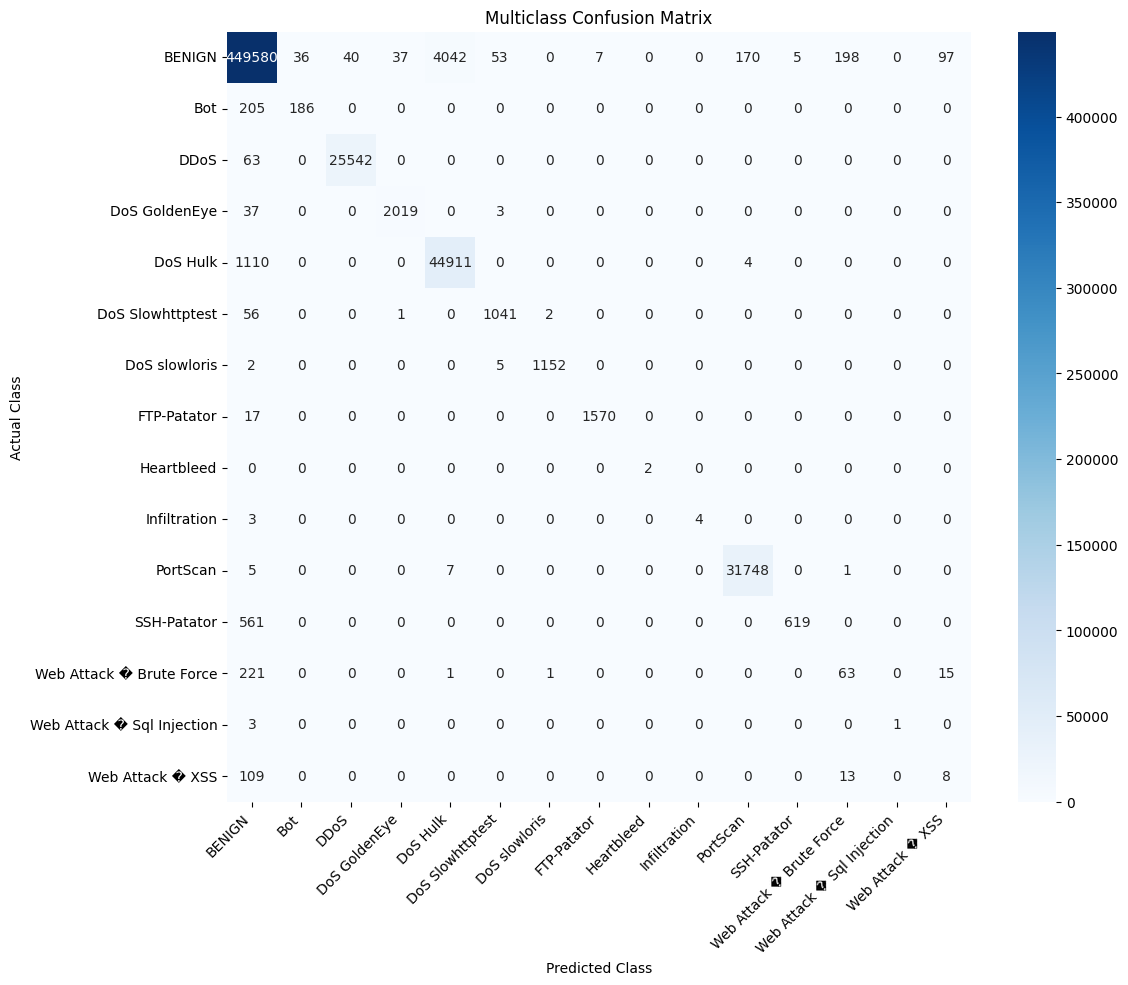

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pull the 15 specific attack names from your label encoder
attack_names = label_encoder.classes_

# ---> ADD THIS LINE TO FIX THE ERROR <---
# This tells the model (clf) to make predictions on the test data
y_pred = clf.predict(X_test) 

# 2. Print the classification report using the correct 15 names
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=attack_names))

# 3. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=attack_names, yticklabels=attack_names)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.title('Multiclass Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.show()

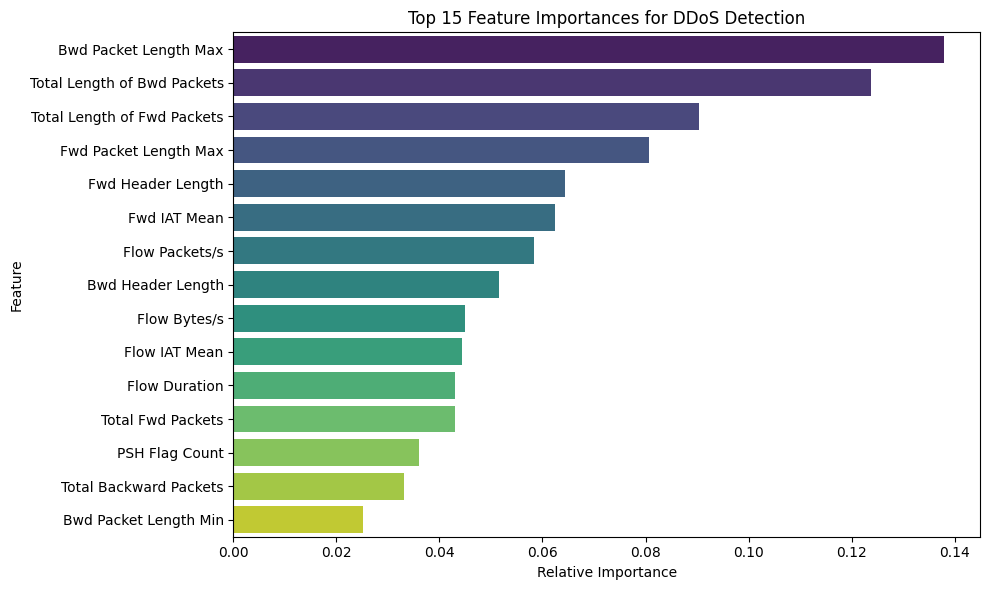

Top 3 Most Important Features:
- Bwd Packet Length Max: 0.1380
- Total Length of Bwd Packets: 0.1237
- Total Length of Fwd Packets: 0.0904


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from the Random Forest model
importances = clf.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': available_features,
    'Importance': importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the Top 15 most important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Feature Importances for DDoS Detection')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Print the Top 3 features
print("Top 3 Most Important Features:")
for i, row in feature_importance_df.head(3).iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.4f}")

## 6. Model Export
We save the trained model as `.pkl` and the list of expected features as `.json` so that the Scapy backend can guarantee array ordering.

In [9]:
import joblib
import json

# Save the model using joblib
model_filename = 'ids_model.pkl'
joblib.dump(clf, model_filename)
print(f"Model successfully saved to {model_filename}")

# Save the feature names so the Scapy script knows exactly what keys to provide and in what order
features_filename = 'model_features.json'
with open(features_filename, 'w') as f:
    json.dump(available_features, f)

print(f"Feature list successfully saved to {features_filename}")
print("The IDS backend can now load these files for real-time packet inference.")

Model successfully saved to ids_model.pkl
Feature list successfully saved to model_features.json
The IDS backend can now load these files for real-time packet inference.
